## Phân tích và Trực quan hóa kết quả OCR Biển số xe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Tải và Gộp dữ liệu

In [8]:
easy_csv = '/Users/binhminh/Project-II/models/ocr/output/results_easy_ocr.csv'
paddle_csv = '/Users/binhminh/Project-II/models/ocr/output/results_paddle_ocr.csv'

def load_data():
    df_e = pd.read_csv(easy_csv) if os.path.exists(easy_csv) else pd.DataFrame()
    df_p = pd.read_csv(paddle_csv) if os.path.exists(paddle_csv) else pd.DataFrame()
    
    if not df_e.empty: df_e['Engine'] = 'EasyOCR'
    if not df_p.empty: df_p['Engine'] = 'PaddleOCR'
    
    return pd.concat([df_e, df_p], ignore_index=True)

df_all = load_data()

## 2. So sánh Độ chính xác 

/var/folders/5b/lg2597jn17z4b_yr082m88tm0000gn/T/ipykernel_18652/2881193917.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='Engine', y='ca_full', palette='magma', errorbar=None)


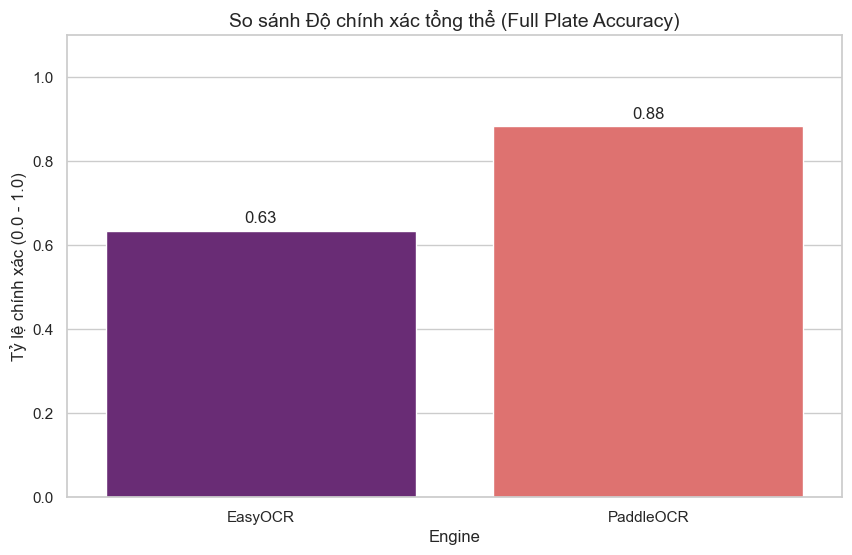

In [ ]:
def plot_accuracy(df):
    if df.empty: 
        print("Không có dữ liệu để hiển thị.")
        return
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df, x='Engine', y='ca_full', palette='magma', errorbar=None)
    
    plt.title('So sánh Độ chính xác tổng thể (Full Plate Accuracy)', fontsize=14)
    plt.ylabel('Tỷ lệ chính xác (0.0 - 1.0)')
    plt.ylim(0, 1.1)
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', xytext = (0, 9), 
                   textcoords = 'offset points')
    plt.show()

plot_accuracy(df_all)

## 3. Phân tích Thời gian xử lý

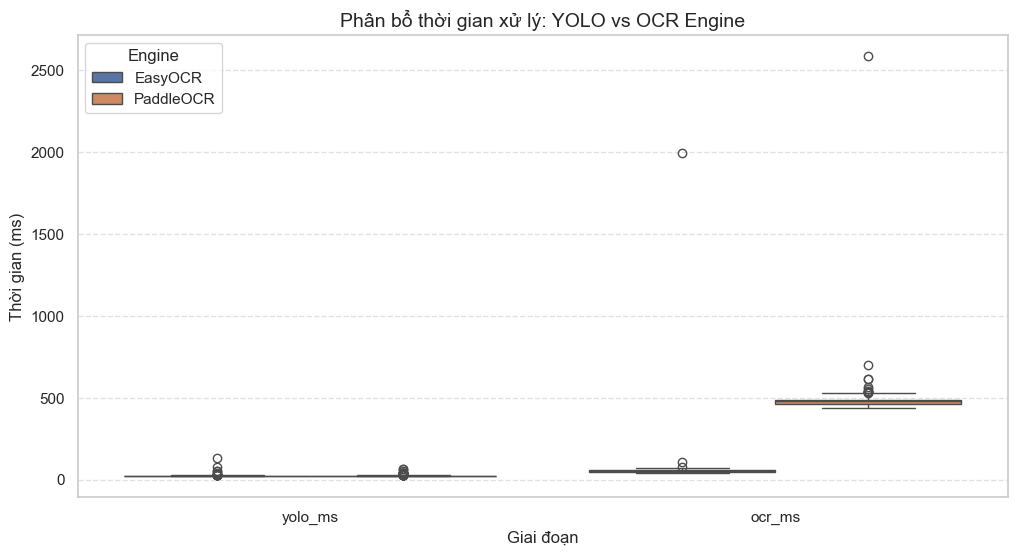

In [ ]:
def plot_latency(df):
    if df.empty: return
    
    df_melted = pd.melt(df, id_vars=['Engine'], value_vars=['yolo_ms', 'ocr_ms'],
                        var_name='Giai đoạn', value_name='Thời gian (ms)')
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_melted, x='Giai đoạn', y='Thời gian (ms)', hue='Engine')
    plt.title('Phân bổ thời gian xử lý: YOLO vs OCR Engine', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

plot_latency(df_all)

## 4. Độ chính xác theo từng thành phần

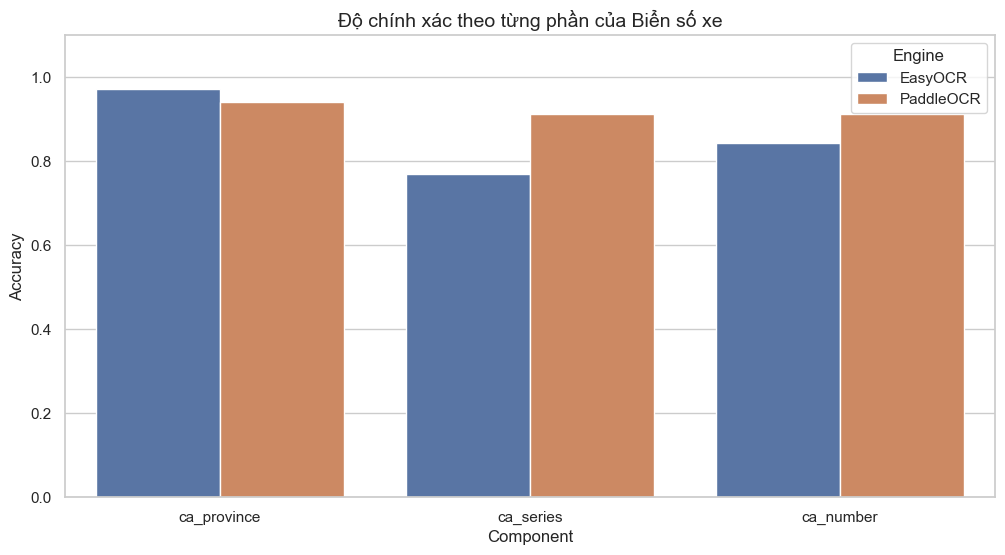

In [11]:
def plot_components(df):
    if df.empty: return
    
    comp_cols = ['ca_province', 'ca_series', 'ca_number']
    summary = df.groupby('Engine')[comp_cols].mean().reset_index()
    summary = pd.melt(summary, id_vars='Engine', var_name='Component', value_name='Accuracy')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=summary, x='Component', y='Accuracy', hue='Engine')
    plt.title('Độ chính xác theo từng phần của Biển số xe', fontsize=14)
    plt.ylim(0, 1.1)
    plt.show()

plot_components(df_all)